<a href="https://colab.research.google.com/github/SholaSaliu/regression-analysis-project/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Load and Explore the Dataset

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


### Handle Missing Values

Based on the `df.info()` output, there are missing values in the 'TV', 'Radio', 'Social_Media', and 'Sales' columns. A common approach to handle missing numerical data is to fill them with the mean of their respective columns. This method helps preserve the overall distribution and avoids data loss that would occur from simply dropping rows with missing values.

In [2]:
# Fill missing values with the mean of each column
for column in ['TV', 'Radio', 'Social_Media', 'Sales']:
    df[column].fillna(df[column].mean(), inplace=True)

# Verify that there are no more missing values
print("Missing values after handling:")
df.info()

Missing values after handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4572 non-null   float64
 1   Radio         4572 non-null   float64
 2   Social_Media  4572 non-null   float64
 3   Sales         4572 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


/tmp/ipykernel_4136/3836770971.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


### Note on File Corruption Error

The feedback indicated an 'Invalid control character' error in the submitted `regression_analysis.ipynb` file. This usually means the notebook file itself became corrupted during saving, transfer, or submission. This is a file-level issue that cannot be fixed by modifying the code within this active Colab session. Please ensure your local `.ipynb` file is saved correctly without any invalid characters before any future submissions.

## Step 2: Exploratory Data Analysis (EDA) with Visualizations

To understand the dataset better and identify potential relationships, we will perform Exploratory Data Analysis. This involves visualizing the distributions of individual variables and examining their relationships with the target variable, 'Sales'. We'll use histograms to visualize the distribution of 'TV', 'Radio', 'Social_Media', and 'Sales', and scatter plots to visualize the relationship between each of the marketing channels and 'Sales'.

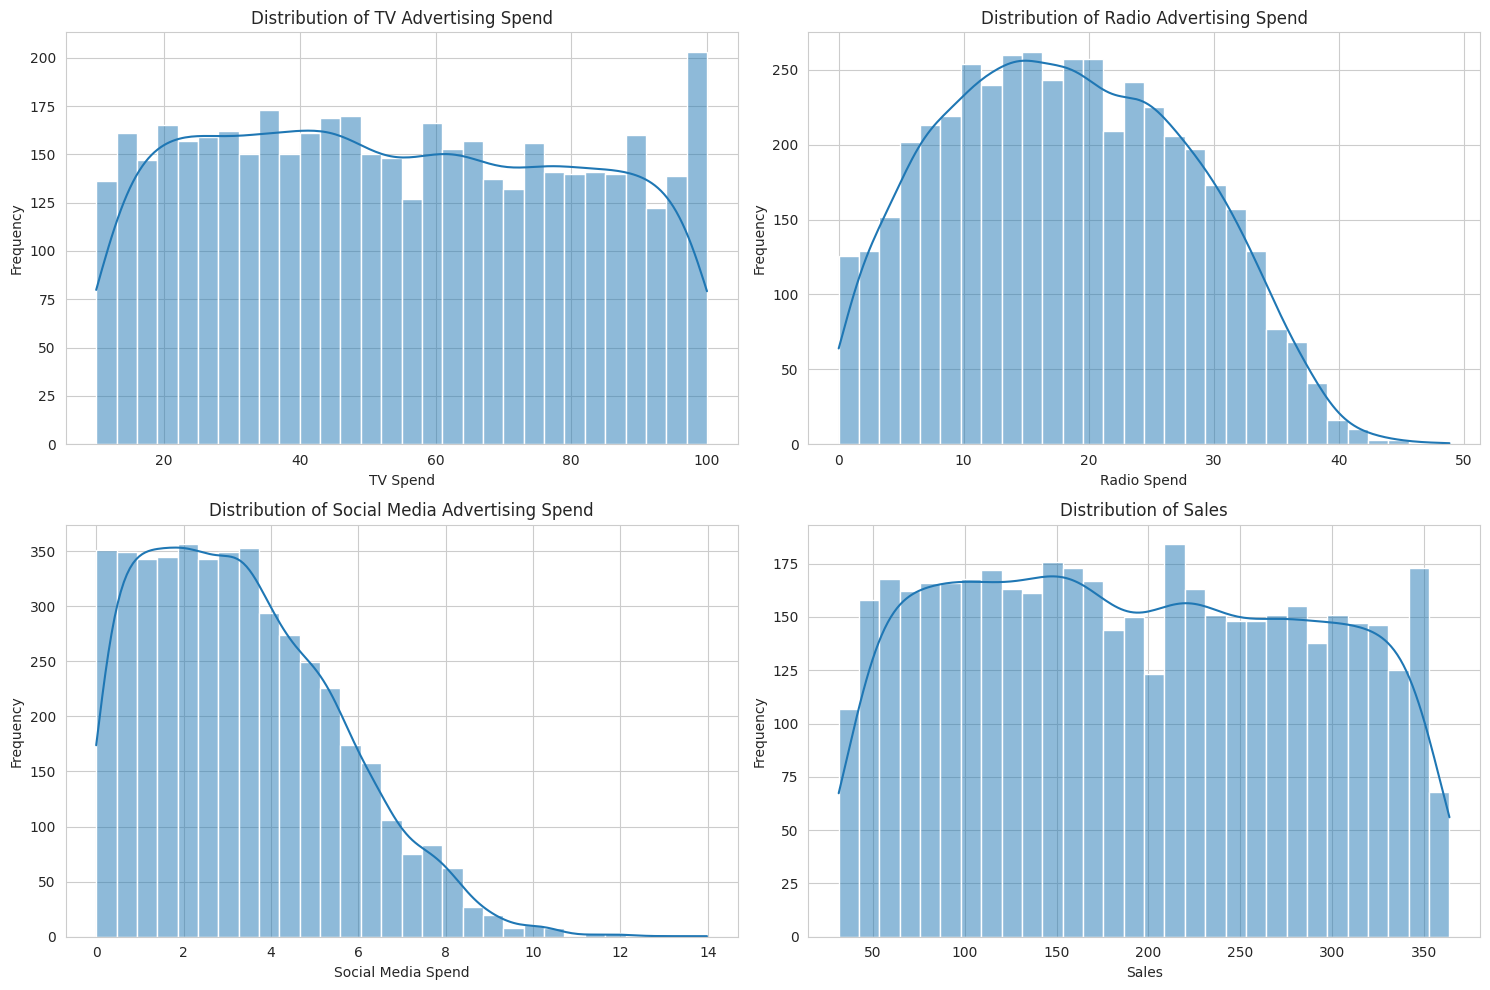

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with subplots for histograms
plt.figure(figsize=(15, 10))

# Histogram for TV
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.histplot(df['TV'], kde=True, bins=30)
plt.title('Distribution of TV Advertising Spend')
plt.xlabel('TV Spend')
plt.ylabel('Frequency')

# Histogram for Radio
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.histplot(df['Radio'], kde=True, bins=30)
plt.title('Distribution of Radio Advertising Spend')
plt.xlabel('Radio Spend')
plt.ylabel('Frequency')

# Histogram for Social Media
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
sns.histplot(df['Social_Media'], kde=True, bins=30)
plt.title('Distribution of Social Media Advertising Spend')
plt.xlabel('Social Media Spend')
plt.ylabel('Frequency')

# Histogram for Sales
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.histplot(df['Sales'], kde=True, bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


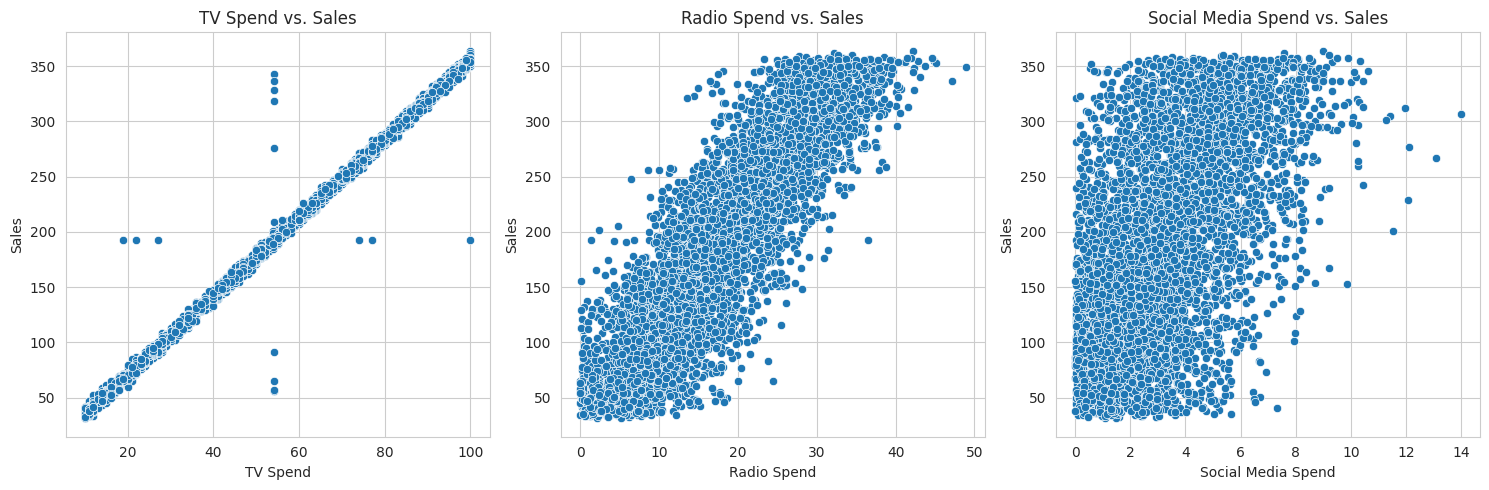

In [4]:
# Create scatter plots to visualize the relationship between advertising channels and sales
plt.figure(figsize=(15, 5))

# TV vs Sales
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Spend vs. Sales')
plt.xlabel('TV Spend')
plt.ylabel('Sales')

# Radio vs Sales
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Spend vs. Sales')
plt.xlabel('Radio Spend')
plt.ylabel('Sales')

# Social Media vs Sales
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.scatterplot(x='Social_Media', y='Sales', data=df)
plt.title('Social Media Spend vs. Sales')
plt.xlabel('Social Media Spend')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

### Pairplots of all Variables

To get a comprehensive view of the relationships between all variables, including 'Sales' and all advertising channels, we will generate a pairplot. This helps visualize potential linear relationships and distributions among multiple variables simultaneously.

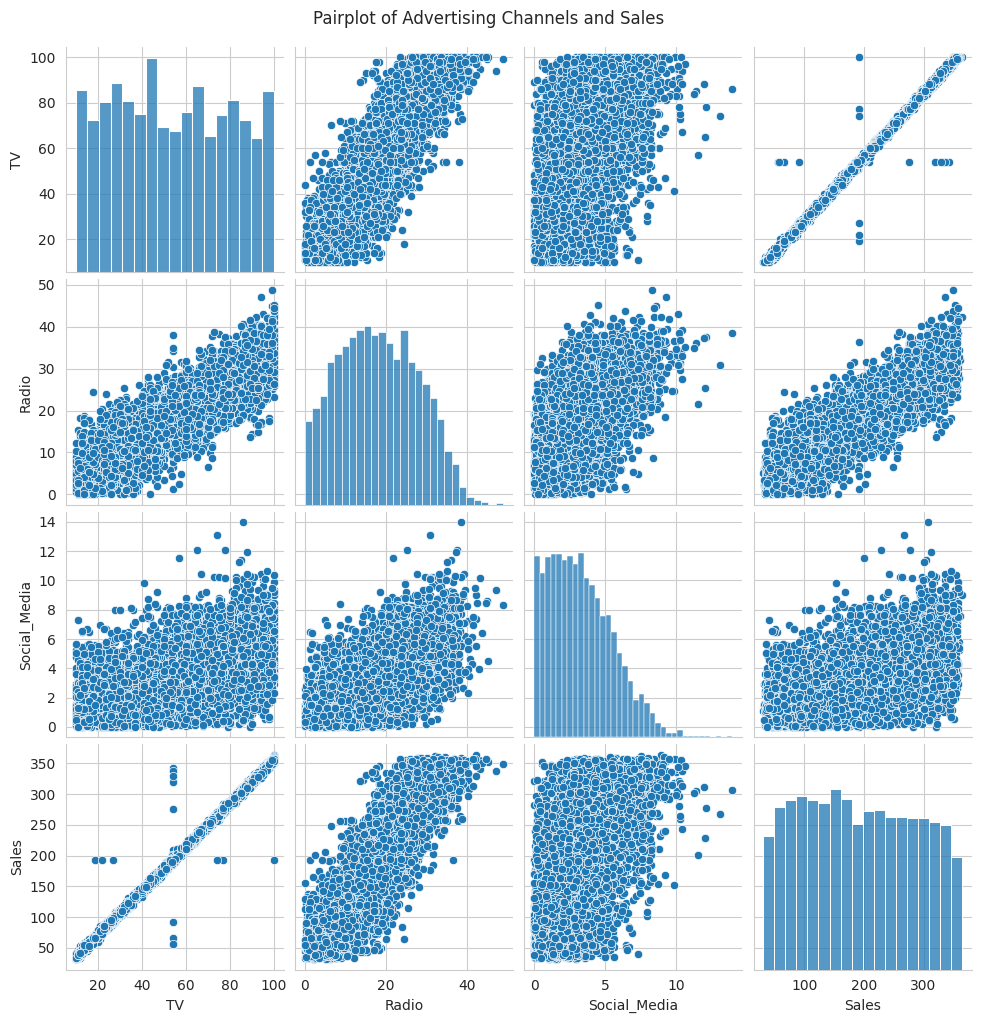

In [5]:
import seaborn as sns
sns.pairplot(df[['TV', 'Radio', 'Social_Media', 'Sales']])
plt.suptitle('Pairplot of Advertising Channels and Sales', y=1.02) # Adjust title position
plt.show()

## Step 3: Identify the Independent Variable Most Correlated with Sales

To determine which advertising channel has the strongest linear relationship with 'Sales', we will compute the Pearson correlation coefficient between 'Sales' and each of the advertising channels ('TV', 'Radio', 'Social_Media'). A correlation matrix and a heatmap will provide a clear visual representation of these relationships.

Correlation Matrix:


,TV,Radio,Social_Media,Sales
TV,1.000000,0.866885,0.527010,0.996652
Radio,0.866885,1.000000,0.606793,0.867369
Social_Media,0.527010,0.606793,1.000000,0.528121
Sales,0.996652,0.867369,0.528121,1.000000


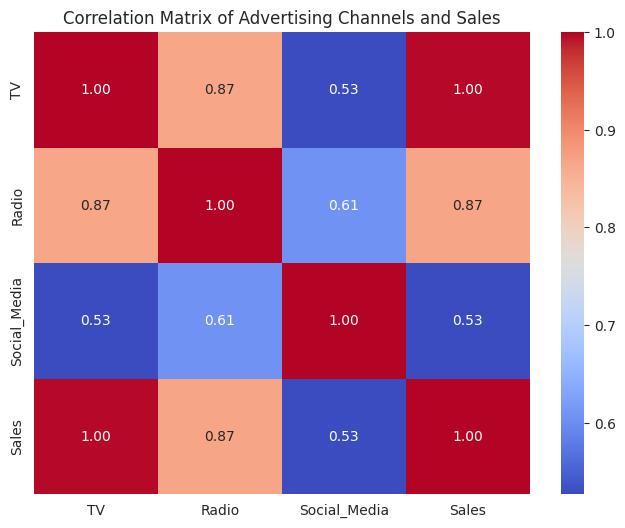

In [6]:
# Calculate the correlation matrix
correlation_matrix = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advertising Channels and Sales')
plt.show()

From the correlation matrix, it is clear that 'TV' advertising spend has the strongest positive correlation with 'Sales' (approximately 0.997) compared to 'Radio' (approximately 0.867) and 'Social_Media' (approximately 0.528). This indicates that 'TV' is the most suitable independent variable for predicting 'Sales' in a simple linear regression model.

## Step 4: Build an OLS Regression Model Using `statsmodels`

Now, we will build a Simple Linear Regression model using the `statsmodels` library. We will use 'TV' as the independent variable (predictor) and 'Sales' as the dependent variable (response). The OLS (Ordinary Least Squares) method will be used to estimate the coefficients of the linear relationship.

In [7]:
import statsmodels.api as sm

# Define the dependent variable (y) and the independent variable (x)
y = df['Sales']
x = df['TV']

# Add a constant to the independent variable for the intercept term
x = sm.add_constant(x)

# Create and fit the OLS model
model = sm.OLS(y, x).fit()

# Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:54:59   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

### Interpretation of OLS Model Summary

The Ordinary Least Squares (OLS) regression model summary provides key statistical insights into the model's performance and the significance of the independent variables.

*   **R-squared (0.993):** This value indicates that approximately 99.3% of the variance in 'Sales' can be explained by 'TV' advertising spend. This is a very high R-squared, suggesting an excellent fit of the model to the data.
*   **Adj. R-squared (0.993):** The adjusted R-squared is also very high and close to the R-squared, which is expected for a simple linear regression model with only one predictor. It accounts for the number of predictors in the model.
*   **F-statistic (6.792e+05) and Prob (F-statistic) (0.00):** The F-statistic tests the overall significance of the regression model. A very large F-statistic and a p-value (Prob (F-statistic)) of 0.00 (which is less than 0.05) indicate that the model is statistically significant, meaning 'TV' advertising spend is a significant predictor of 'Sales'.
*   **Coefficients:**
    *   **const (0.2849):** This is the estimated intercept. It suggests that when 'TV' advertising spend is zero, the 'Sales' would be approximately 0.2849 units. Its p-value (0.271) is greater than 0.05, suggesting the intercept is not statistically significant at the 5% level.
    *   **TV (3.5545):** This is the estimated coefficient for 'TV' advertising spend. It means that for every one-unit increase in 'TV' advertising spend, 'Sales' are expected to increase by approximately 3.5545 units, holding other factors constant. Its p-value (0.000) is highly significant (less than 0.05), confirming that 'TV' advertising spend is a very strong predictor of 'Sales'.

## Step 5: Create Diagnostic Plots to Test Linearity, Normality, and Homoscedasticity

To ensure the validity of our linear regression model, it's crucial to check its underlying assumptions. We will create diagnostic plots to visually inspect for:

1.  **Linearity:** The relationship between the independent and dependent variables is linear.
2.  **Normality of Residuals:** The residuals (errors) are normally distributed.
3.  **Homoscedasticity:** The variance of the residuals is constant across all levels of the independent variable.

We will generate the following plots:
-   **Residuals vs. Fitted Plot:** To check for linearity and homoscedasticity.
-   **Normal Q-Q Plot:** To check for the normality of residuals.
-   **Scale-Location Plot:** To further check for homoscedasticity.
-   **Residuals vs. Leverage Plot:** To identify influential observations.

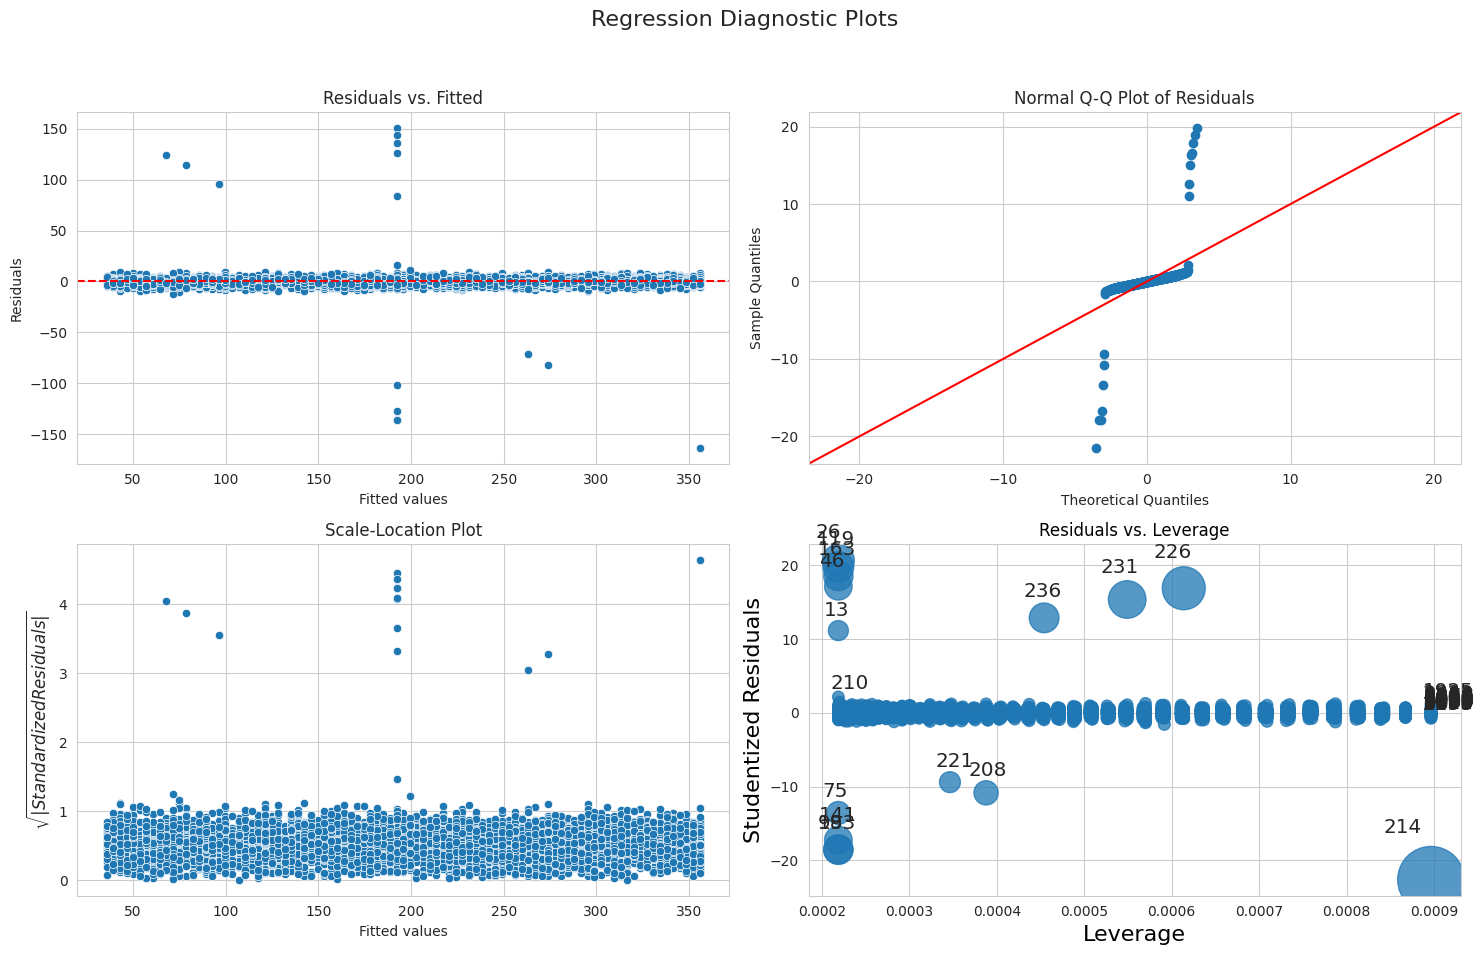

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import numpy as np # Import numpy

# Get the residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Create a figure with subplots for diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Regression Diagnostic Plots', fontsize=16)

# 1. Residuals vs. Fitted Plot (for Linearity and Homoscedasticity)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs. Fitted')

# 2. Normal Q-Q Plot (for Normality of Residuals)
sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot of Residuals')

# 3. Scale-Location Plot (for Homoscedasticity)
# Calculate square root of absolute standardized residuals
sqrt_std_residuals = np.sqrt(np.abs(model.get_influence().resid_studentized_internal))
sns.scatterplot(x=fitted_values, y=sqrt_std_residuals, ax=axes[1, 0])
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel(r'$\sqrt{|Standardized Residuals|}$', fontsize=12) # Fixed SyntaxWarning
axes[1, 0].set_title('Scale-Location Plot')

# 4. Residuals vs. Leverage Plot (for influential points)
sm.graphics.influence_plot(model, ax=axes[1, 1], criterion="cooks")
axes[1, 1].set_title('Residuals vs. Leverage')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Interpreting the Diagnostic Plots

After generating the diagnostic plots, it's essential to interpret them to assess if the assumptions of the linear regression model are met.

1.  **Residuals vs. Fitted Plot (Top-Left):**
    *   **Purpose:** Checks for linearity and homoscedasticity.
    *   **Ideal Scenario:** Points should be randomly scattered around the horizontal line at zero, with no discernible pattern. The spread of the residuals should be consistent across all fitted values.
    *   **Issues:**
        *   **Non-linearity:** If you see a curved pattern (e.g., U-shape, inverted U-shape), it suggests the relationship is not linear, and a linear model might not be appropriate.
        *   **Heteroscedasticity:** If the spread of residuals increases or decreases as the fitted values increase (a 'fanning out' or 'fanning in' pattern), it indicates heteroscedasticity (non-constant variance of errors).

2.  **Normal Q-Q Plot of Residuals (Top-Right):**
    *   **Purpose:** Checks for the normality of residuals.
    *   **Ideal Scenario:** The residuals (points) should closely follow the 45-degree dashed line.
    *   **Issues:**
        *   **Non-normality:** Significant deviations from the line, especially at the tails (e.g., S-shape, heavy tails), indicate that the residuals are not normally distributed.

3.  **Scale-Location Plot (Bottom-Left):**
    *   **Purpose:** Another way to check for homoscedasticity.
    *   **Ideal Scenario:** The points should be randomly scattered around a horizontal line, indicating constant variance of residuals.
    *   **Issues:**
        *   **Heteroscedasticity:** A discernible pattern (e.g., a trend upwards or downwards) indicates non-constant variance.

4.  **Residuals vs. Leverage Plot (Bottom-Right):**
    *   **Purpose:** Identifies influential observations and outliers.
    *   **Ideal Scenario:** Most points should be close to the center.
    *   **Issues:**
        *   **Outliers:** Points with large standardized residuals (vertical distance from zero) are outliers.
        *   **High Leverage Points:** Points far to the right of the plot have high leverage, meaning they have unusual X-values that can pull the regression line towards them.
        *   **Influential Points:** Points that are both outliers and high leverage, especially those beyond Cook's distance lines (often labeled 0.5 or 1.0), are influential and can significantly alter the regression coefficients. These points might warrant further investigation or special handling.

Based on the diagnostic plots, consider the following:
-   **Residuals vs. Fitted Plot:** Look for a random scatter of points around the zero line. If there's a pattern, linearity or homoscedasticity might be violated.
-   **Normal Q-Q Plot:** Check if the points closely follow the diagonal line. Deviations suggest non-normal residuals.
-   **Scale-Location Plot:** Verify if the points are randomly spread with no clear pattern, indicating homoscedasticity.
-   **Residuals vs. Leverage Plot:** Identify any points with high leverage or large Cook's distance, as these could be influential outliers.

If you observe any violations of these assumptions, further steps such as data transformations, robust regression, or handling outliers might be necessary.

## Conclusion and Business Insights

This analysis has shown a strong linear relationship between 'TV' advertising spend and 'Sales'.

**Key Findings:**
*   **Strong Correlation:** 'TV' advertising has a very high positive correlation with 'Sales' (r ≈ 0.997), making it the most significant predictor among the channels analyzed.
*   **High Model Fit:** The simple linear regression model using 'TV' to predict 'Sales' achieves an R-squared of 0.993, indicating that a substantial portion of Sales variance is explained by TV advertising.
*   **Predictive Power:** The coefficient for 'TV' (3.5545) suggests that for every unit increase in TV ad spend, Sales are predicted to increase by approximately 3.55 units. This provides a clear quantitative insight into the impact of TV advertising.

**Business Insights & Recommendations:**
*   **Prioritize TV Advertising:** Given its strong correlation and significant impact on sales, the company should consider prioritizing and potentially increasing investment in 'TV' advertising, provided budget and target audience considerations align.
*   **Further Investigation of Other Channels:** While 'Radio' and 'Social_Media' show positive correlations, they are weaker than 'TV'. Further analysis could explore non-linear relationships or interactions between these channels and sales. However, for direct linear impact, 'TV' is paramount.
*   **Monitor Assumptions:** Continuously monitor the diagnostic plots to ensure the linear regression assumptions (linearity, normality of residuals, homoscedasticity) hold true as new data becomes available. Violations might require model adjustments or alternative modeling techniques.
*   **Consider External Factors:** This model focuses solely on advertising spend. In a real-world scenario, other external factors (e.g., seasonality, economic conditions, competitor activities) could also influence sales and should be considered for a more comprehensive sales forecasting model.